# Задача 3. Реализация обхода в ширину из нескольких стартовых вершин (Multiple-Source BFS)
## Настройка виртуального окружения
```bash
python -m venv .venv

source .venv/Scripts/activate

pip install -r req.txt
```

In [381]:
# Импорт необходимых библиотек

import graphblas as gb
from graphblas import Matrix, Vector, Scalar, dtypes
from graphblas import unary, binary, monoid, semiring
from graphblas.io import mmread

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import os
import time

In [382]:
edges = [
    [3, 0, 3, 5, 6, 0, 6, 1, 6, 2, 4, 1],
    [0, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6],
]

A = Matrix.from_coo(edges[0], edges[1], [True for _ in edges[0]])
A

"M_4172828"  nvals  nrows  ncols  dtype         format
gb.Matrix       12      7      7   BOOL  bitmapr (iso)
------------------------------------------------------
      0     1     2     3     4     5     6
0        True        True                  
1                          True        True
2                                True      
3  True        True                        
4                                True      
5              True                        
6              True  True  True

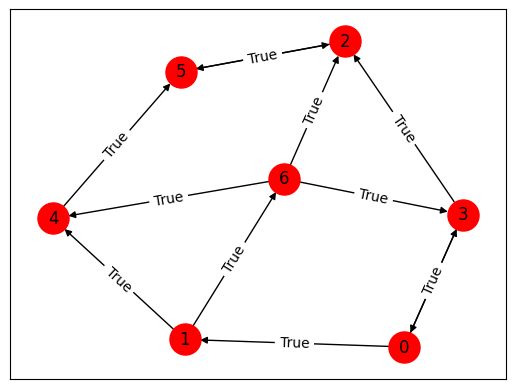

In [383]:
gb.viz.draw(A)

Везде считаем, что вершины графа занумерованы подряд с нуля.

✔️ (выполнено) Используя `python-graphblas` реализовать функцию обхода ориентированного графа (`MSBFS-Levels`) в ширину из нескольких заданных стартовых вершин.
- Функция принимает представление графа, удобное для неё (загрузка, конвертация реализованы отдельно) и массив номеров стартовых вершин.
- Функция возвращает массив пар: стартовая вершина, и массив (`levels`), где для каждой вершины указано, на каком уровне она достижима из этой стартовой. Стартовая вершина достижима на нулевом уровне, если вершина не достижима, то значение соответствующей ячейки сделайте равной -1.

In [384]:
def msbfs_levels(graph, start_points, semiring = semiring.lor_land):
    level_results = []
    N = graph.nrows

    if not isinstance(start_points, list):
        start_points = [start_points]

    for point in start_points:
        levels = Vector(dtypes.INT32, N)
        f = Vector(bool, N)
        f[point] << True
        current_level = 0

        for _ in range(N):
            levels(mask = f.V) << current_level
            current_level += 1
            f(~levels.S, replace=True) << f.vxm(graph, semiring)

        levels(~levels.S) << -1
        level_results.append((point, [levels.get(i, default = -1) for i in range(N)]))

    return level_results

In [385]:
# Начальная точка - 4
msbfs_levels(A, start_points = [4])

[(4, [-1, -1, 2, -1, 0, 1, -1])]

In [386]:
# Начальные первые 4 точки
msbfs_levels(A, start_points = [0, 1, 2, 3])

[(0, [0, 1, 2, 1, 2, 3, 2]),
 (1, [3, 0, 2, 2, 1, 2, 1]),
 (2, [-1, -1, 0, -1, -1, 1, -1]),
 (3, [1, 2, 1, 0, 3, 2, 3])]

✔️ Используя `python-graphblas` реализовать функцию обхода ориентированного графа (`MSBFS-Parents`) в ширину из нескольких заданных стартовых вершин.
- Функция принимает представление графа, удобное для неё (загрузка, конвертация реализованы отдельно) и массив номеров стартовых вершин.
- Функция возвращает массив пар: стартовая вершина, и массив (`parents`), где для каждой вершины графа указано, из какой вершины мы пришли в эту по кратчайшему пути из стартовой вершины. При этом для самой стартовой вершины такое значение взять равное -1, а для недостижимых вершин взять равное -2. При наличии нескольких возможных значений в массивах `parents` брать наименьшее.

In [387]:
def msbfs_parents(A, start_points, semiring = semiring.min_first):
    parents_result = []
    N = A.nrows
    
    if not isinstance(start_points, list):
        start_points = [start_points]
        
    for start in start_points:
        index_ramp = Vector(dtypes.INT32, N)
        index_ramp.build(range(N), range(N))
        
        parents = Vector(dtypes.INT32, N)
        parents[start] << -1
        
        wavefront = Vector(dtypes.INT32, N)
        wavefront[start] << -1
        
        while wavefront.nvals > 0:
            wavefront << index_ramp.ewise_mult(wavefront, binary.first)
            wavefront(~parents.S, replace = True) << wavefront.vxm(A, semiring)
            parents(binary.plus) << wavefront
            
        parents(~parents.S) << -2
        parents_result.append((start, [parents.get(node, default = -1) for node in range(N)]))
        
    return parents_result

In [388]:
# Начальная точка - 4
msbfs_parents(A, start_points = [4])

[(4, [-2, -2, 5, -2, -1, 4, -2])]

In [389]:
# Начальные первые 4 точки
msbfs_parents(A, start_points = [0, 1, 2, 3])

[(0, [-1, 0, 3, 0, 1, 2, 1]),
 (1, [3, -1, 6, 6, 1, 4, 1]),
 (2, [-2, -2, -1, -2, -2, 2, -2]),
 (3, [3, 0, 3, -1, 1, 2, 1])]

✔️ Добавить тесты для проверки корректности полученных реализаций.

In [390]:
def test_msbfs_levels():
    edges = [
		[3, 0, 3, 5, 6, 0, 6, 1, 6, 2, 4, 1],
		[0, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6],
	]
    
    A = Matrix.from_coo(edges[0], edges[1], [True for _ in edges[0]])
    # Тест 1: Проверка уровней для одной стартовой точки
    result = msbfs_levels(A, [0])
    assert result == [(0, [0, 1, 2, 1, 2, 3, 2])]

    # Тест 2: Проверка уровней для нескольких стартовых точек
    result = msbfs_levels(A, [0, 3])
    assert result == [
        (0, [0, 1, 2, 1, 2, 3, 2]),
        (3, [1, 2, 1, 0, 3, 2, 3])
    ]

    # Тест 3: Граф с изолированными узлами
    edges = [
        [0, 1],
        [1, 0],
    ]
    graph = Matrix.from_coo(edges[0], edges[1], [1] * len(edges[0]), nrows = 4, ncols = 4)
    result = msbfs_levels(graph, [0])
    assert result == [(0, [0, 1, -1, -1])]
    print("Все тесты пройдены!")

In [391]:
def test_msbfs_parents():
    edges = [
		[3, 0, 3, 5, 6, 0, 6, 1, 6, 2, 4, 1],
		[0, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6],
	]
    
    A = Matrix.from_coo(edges[0], edges[1], [True for _ in edges[0]])
    # Тест 1: Проверка поиска родителей для одной стартовой точки
    result = msbfs_parents(A, [0])
    assert result == [(0, [-1, 0, 3, 0, 1, 2, 1])]

    # Тест 2: Проверка поиска родителей для нескольких стартовых точек
    result = msbfs_parents(A, [0, 3])
    assert result == [
        (0, [-1, 0, 3, 0, 1, 2, 1]),
        (3, [3, 0, 3, -1, 1, 2, 1])
    ]

    # Тест 3: Граф с изолированными узлами
    edges = [
        [0, 1],
        [1, 0],
    ]
    graph = Matrix.from_coo(edges[0], edges[1], [1] * len(edges[0]), nrows=4, ncols=4)
    result = msbfs_parents(graph, [0])
    assert result == [(0, [-1, 0, -2, -2])]
    print("Все тесты пройдены!")

In [392]:
test_msbfs_levels()
test_msbfs_parents()

Все тесты пройдены!
Все тесты пройдены!


✔️ (+2 балла) Провести экспериментальное исследование полученных реализаций на некоторых больших графах в формате `A Market` с сайта [SuiteSparse A Collection](https://sparse.tamu.edu/) и на случайных сгенерированных. При этом описать зависимость времени работы всех полученных реализаций от размеров графа, его степени разреженности, количестве стартовых вершин.

In [393]:
def testTime(A, iters, start_points):
    
	results = {}
	print(f'Размер матрицы: {A.shape[0]}x{A.shape[1]}, число вершин: {len(start_points)}')

	results = {}

	total_time = 0
	for _ in range(iters):
		start = time.perf_counter()
		msbfs_levels(A, start_points)
		total_time += time.perf_counter() - start
	results['msbfs_levels'] = total_time / iters
	
	total_time = 0
	for _ in range(iters):
		start = time.perf_counter()
		msbfs_parents(A, start_points)
		total_time += time.perf_counter() - start
	results['msbfs_parents'] = total_time / iters

	return results

In [394]:
files = os.listdir('./data')

iters = 2
sizes = []
results = {}

start_points = [1, 10, 30, 50]
for i in range(len(files) - 3):
	
	A = mmread(f'./data/{files[i]}')
	results[A.shape[0]] = {'msbfs_levels': [], 'msbfs_parents': []}
 
	for points in start_points:
 
		res = testTime(A, iters, [i for i in range(points)])
		results[A.shape[0]]['msbfs_levels'].append(res['msbfs_levels'])
		results[A.shape[0]]['msbfs_parents'].append(res['msbfs_parents'])

# results

Размер матрицы: 767x767, число вершин: 1
Размер матрицы: 767x767, число вершин: 10
Размер матрицы: 767x767, число вершин: 30
Размер матрицы: 767x767, число вершин: 50
Размер матрицы: 1535x1535, число вершин: 1
Размер матрицы: 1535x1535, число вершин: 10
Размер матрицы: 1535x1535, число вершин: 30
Размер матрицы: 1535x1535, число вершин: 50
Размер матрицы: 3071x3071, число вершин: 1
Размер матрицы: 3071x3071, число вершин: 10
Размер матрицы: 3071x3071, число вершин: 30
Размер матрицы: 3071x3071, число вершин: 50
Размер матрицы: 6143x6143, число вершин: 1
Размер матрицы: 6143x6143, число вершин: 10
Размер матрицы: 6143x6143, число вершин: 30
Размер матрицы: 6143x6143, число вершин: 50


In [395]:
sizes = sorted(results.keys())

msbfs_levels_1 = []
msbfs_levels_10 = []
msbfs_levels_30 = []
msbfs_levels_50 = []

msbfs_parents_1 = []
msbfs_parents_10 = []
msbfs_parents_30 = []
msbfs_parents_50 = []

for size in sizes:
	msbfs_levels_1.append(results[size]['msbfs_levels'][0])
	msbfs_levels_10.append(results[size]['msbfs_levels'][1])
	msbfs_levels_30.append(results[size]['msbfs_levels'][2])
	msbfs_levels_50.append(results[size]['msbfs_levels'][3])

	msbfs_parents_1.append(results[size]['msbfs_parents'][0])
	msbfs_parents_10.append(results[size]['msbfs_parents'][1])
	msbfs_parents_30.append(results[size]['msbfs_parents'][2])
	msbfs_parents_50.append(results[size]['msbfs_parents'][3])

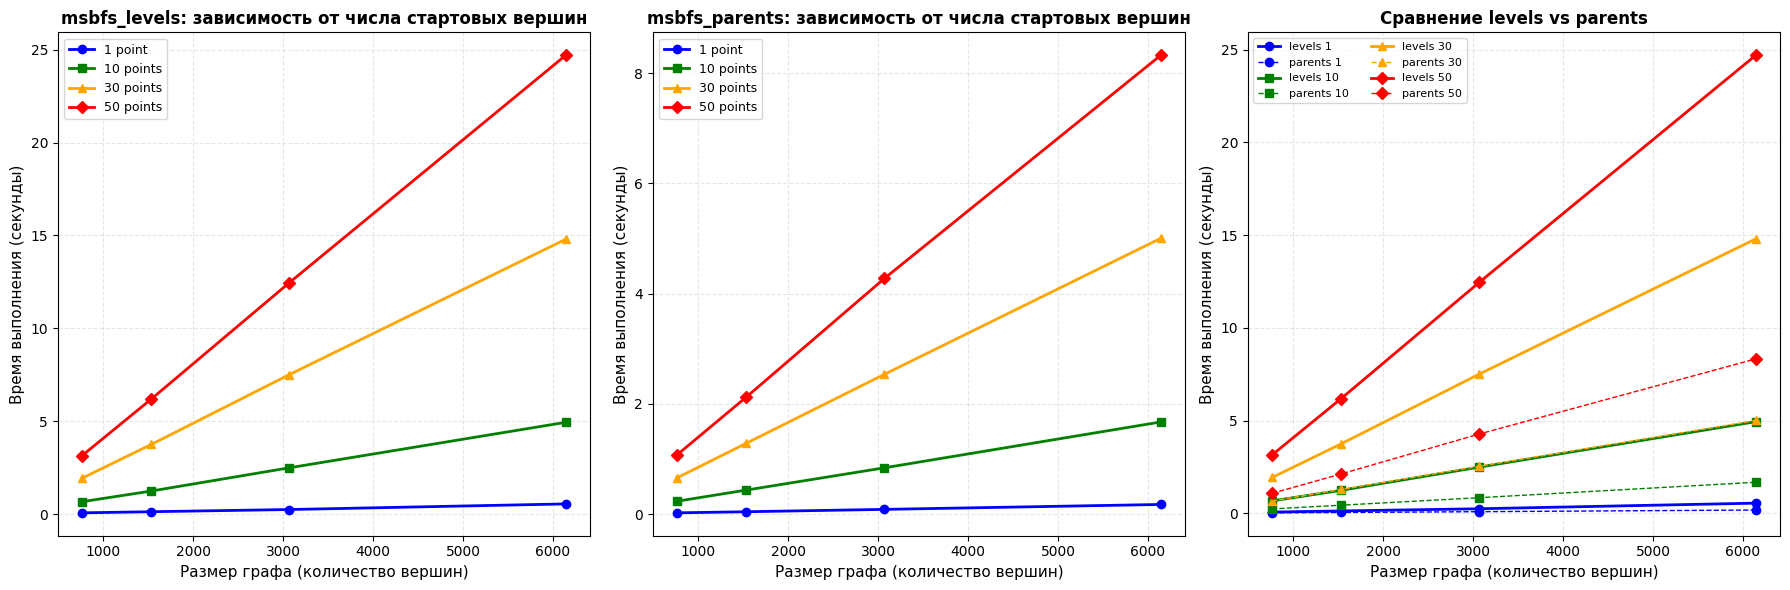

In [396]:
# Создаем фигуру с тремя подграфиками
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Цвета для разных процентов
colors = ['blue', 'green', 'orange', 'red']
markers = ['o', 's', '^', 'D']
percentages = ['1 point', '10 points', '30 points', '50 points']

# График 1: Только msbfs_levels
ax = axes[0]
for i, (msbfs_levels_data, color, marker, label) in enumerate(zip(
    [msbfs_levels_1, msbfs_levels_10, msbfs_levels_30, msbfs_levels_50],
    colors, markers, percentages
)):
    ax.plot(sizes, msbfs_levels_data, 
            color=color, marker=marker, linewidth=2, markersize=6,
            label=f'{label}')
ax.set_xlabel('Размер графа (количество вершин)', fontsize=11)
ax.set_ylabel('Время выполнения (секунды)', fontsize=11)
ax.set_title('msbfs_levels: зависимость от числа стартовых вершин', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')

# График 2: Только msbfs_parents
ax = axes[1]
for i, (msbfs_parents_data, color, marker, label) in enumerate(zip(
    [msbfs_parents_1, msbfs_parents_10, msbfs_parents_30, msbfs_parents_50],
    colors, markers, percentages
)):
    ax.plot(sizes, msbfs_parents_data, 
            color=color, marker=marker, linewidth=2, markersize=6,
            label=f'{label}')
ax.set_xlabel('Размер графа (количество вершин)', fontsize=11)
ax.set_ylabel('Время выполнения (секунды)', fontsize=11)
ax.set_title('msbfs_parents: зависимость от числа стартовых вершин', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')

# График 3: Сравнение levels и parents для каждого процента
ax = axes[2]
for i, percent in enumerate([1, 10, 30, 50]):
    levels_data = [msbfs_levels_1, msbfs_levels_10, msbfs_levels_30, msbfs_levels_50][i]
    parents_data = [msbfs_parents_1, msbfs_parents_10, msbfs_parents_30, msbfs_parents_50][i]
    
    ax.plot(sizes, levels_data, 
            color=colors[i], marker=markers[i], linewidth=2, 
            label=f'levels {percent}')
    ax.plot(sizes, parents_data, 
            color=colors[i], marker=markers[i], linewidth=1, linestyle='--',
            label=f'parents {percent}')
ax.set_xlabel('Размер графа (количество вершин)', fontsize=11)
ax.set_ylabel('Время выполнения (секунды)', fontsize=11)
ax.set_title('Сравнение levels vs parents', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [397]:
def WattsStrogatz(n, sparcity, p = 0.1, seed = 42):
    """
    WS граф с контролем плотности через k
    
    Parameters:
    - n: количество вершин
    - target_sparcity: целевая разреженность
    - p: вероятность пересоединения (структура)
    """

    target_density = 1 - sparcity
    k = int(target_density * (n - 1))
    
    k = max(2, min(k, n - 1))
    if k % 2 != 0:
        k += 1

    G = nx.watts_strogatz_graph(n, k, p, seed=seed)
    
    A_coo = nx.to_scipy_sparse_array(G)
    A_dense = A_coo.toarray()
    A = gb.Matrix.from_dense(A_dense.astype(int))
    
    A = A.select('!=', 0)

    return A

In [398]:
sparsities = [0.99, 0.95, 0.9]
sizes = [i for i in range(100, 301, 50)]

results = {}
iters = 3

for size in sizes:
    results[size] = {}
    
    for sparcity in sparsities:
        print('Размер:', size, 'Разреженность:', sparcity)
        A = WattsStrogatz(size, sparcity)
        results[size][sparcity] = {'msbfs_levels': [], 'msbfs_parents': []}
        
        for points in start_points:
            
            res = testTime(A, iters, [i for i in range(points)])
            results[size][sparcity]['msbfs_levels'].append(res['msbfs_levels'])
            results[size][sparcity]['msbfs_parents'].append(res['msbfs_parents'])

# results

Размер: 100 Разреженность: 0.99
Размер матрицы: 100x100, число вершин: 1
Размер матрицы: 100x100, число вершин: 10
Размер матрицы: 100x100, число вершин: 30
Размер матрицы: 100x100, число вершин: 50
Размер: 100 Разреженность: 0.95
Размер матрицы: 100x100, число вершин: 1
Размер матрицы: 100x100, число вершин: 10
Размер матрицы: 100x100, число вершин: 30
Размер матрицы: 100x100, число вершин: 50
Размер: 100 Разреженность: 0.9
Размер матрицы: 100x100, число вершин: 1
Размер матрицы: 100x100, число вершин: 10
Размер матрицы: 100x100, число вершин: 30
Размер матрицы: 100x100, число вершин: 50
Размер: 150 Разреженность: 0.99
Размер матрицы: 150x150, число вершин: 1
Размер матрицы: 150x150, число вершин: 10
Размер матрицы: 150x150, число вершин: 30
Размер матрицы: 150x150, число вершин: 50
Размер: 150 Разреженность: 0.95
Размер матрицы: 150x150, число вершин: 1
Размер матрицы: 150x150, число вершин: 10
Размер матрицы: 150x150, число вершин: 30
Размер матрицы: 150x150, число вершин: 50
Размер

In [399]:
msbfs_levels_99_1 = []
msbfs_levels_99_10 = []
msbfs_levels_99_30 = []
msbfs_levels_99_50 = []

msbfs_parents_99_1 = []
msbfs_parents_99_10 = []
msbfs_parents_99_30 = []
msbfs_parents_99_50 = []

msbfs_levels_95_1 = []
msbfs_levels_95_10 = []
msbfs_levels_95_30 = []
msbfs_levels_95_50 = []

msbfs_parents_95_1 = []
msbfs_parents_95_10 = []
msbfs_parents_95_30 = []
msbfs_parents_95_50 = []

msbfs_levels_9_1 = []
msbfs_levels_9_10 = []
msbfs_levels_9_30 = []
msbfs_levels_9_50 = []

msbfs_parents_9_1 = []
msbfs_parents_9_10 = []
msbfs_parents_9_30 = []
msbfs_parents_9_50 = []

for size in sizes:
    for sparcity in sparsities:
        if sparcity == 0.99:
            msbfs_levels_99_1.append(results[size][sparcity]['msbfs_levels'][0])
            msbfs_levels_99_10.append(results[size][sparcity]['msbfs_levels'][1])
            msbfs_levels_99_30.append(results[size][sparcity]['msbfs_levels'][2])
            msbfs_levels_99_50.append(results[size][sparcity]['msbfs_levels'][3])

            msbfs_parents_99_1.append(results[size][sparcity]['msbfs_parents'][0])
            msbfs_parents_99_10.append(results[size][sparcity]['msbfs_parents'][1])
            msbfs_parents_99_30.append(results[size][sparcity]['msbfs_parents'][2])
            msbfs_parents_99_50.append(results[size][sparcity]['msbfs_parents'][3])
            
        elif sparcity == 0.95:
            msbfs_levels_95_1.append(results[size][sparcity]['msbfs_levels'][0])
            msbfs_levels_95_10.append(results[size][sparcity]['msbfs_levels'][1])
            msbfs_levels_95_30.append(results[size][sparcity]['msbfs_levels'][2])
            msbfs_levels_95_50.append(results[size][sparcity]['msbfs_levels'][3])

            msbfs_parents_95_1.append(results[size][sparcity]['msbfs_parents'][0])
            msbfs_parents_95_10.append(results[size][sparcity]['msbfs_parents'][1])
            msbfs_parents_95_30.append(results[size][sparcity]['msbfs_parents'][2])
            msbfs_parents_95_50.append(results[size][sparcity]['msbfs_parents'][3])
            
        elif sparcity == 0.9:
            msbfs_levels_9_1.append(results[size][sparcity]['msbfs_levels'][0])
            msbfs_levels_9_10.append(results[size][sparcity]['msbfs_levels'][1])
            msbfs_levels_9_30.append(results[size][sparcity]['msbfs_levels'][2])
            msbfs_levels_9_50.append(results[size][sparcity]['msbfs_levels'][3])

            msbfs_parents_9_1.append(results[size][sparcity]['msbfs_parents'][0])
            msbfs_parents_9_10.append(results[size][sparcity]['msbfs_parents'][1])
            msbfs_parents_9_30.append(results[size][sparcity]['msbfs_parents'][2])
            msbfs_parents_9_50.append(results[size][sparcity]['msbfs_parents'][3])

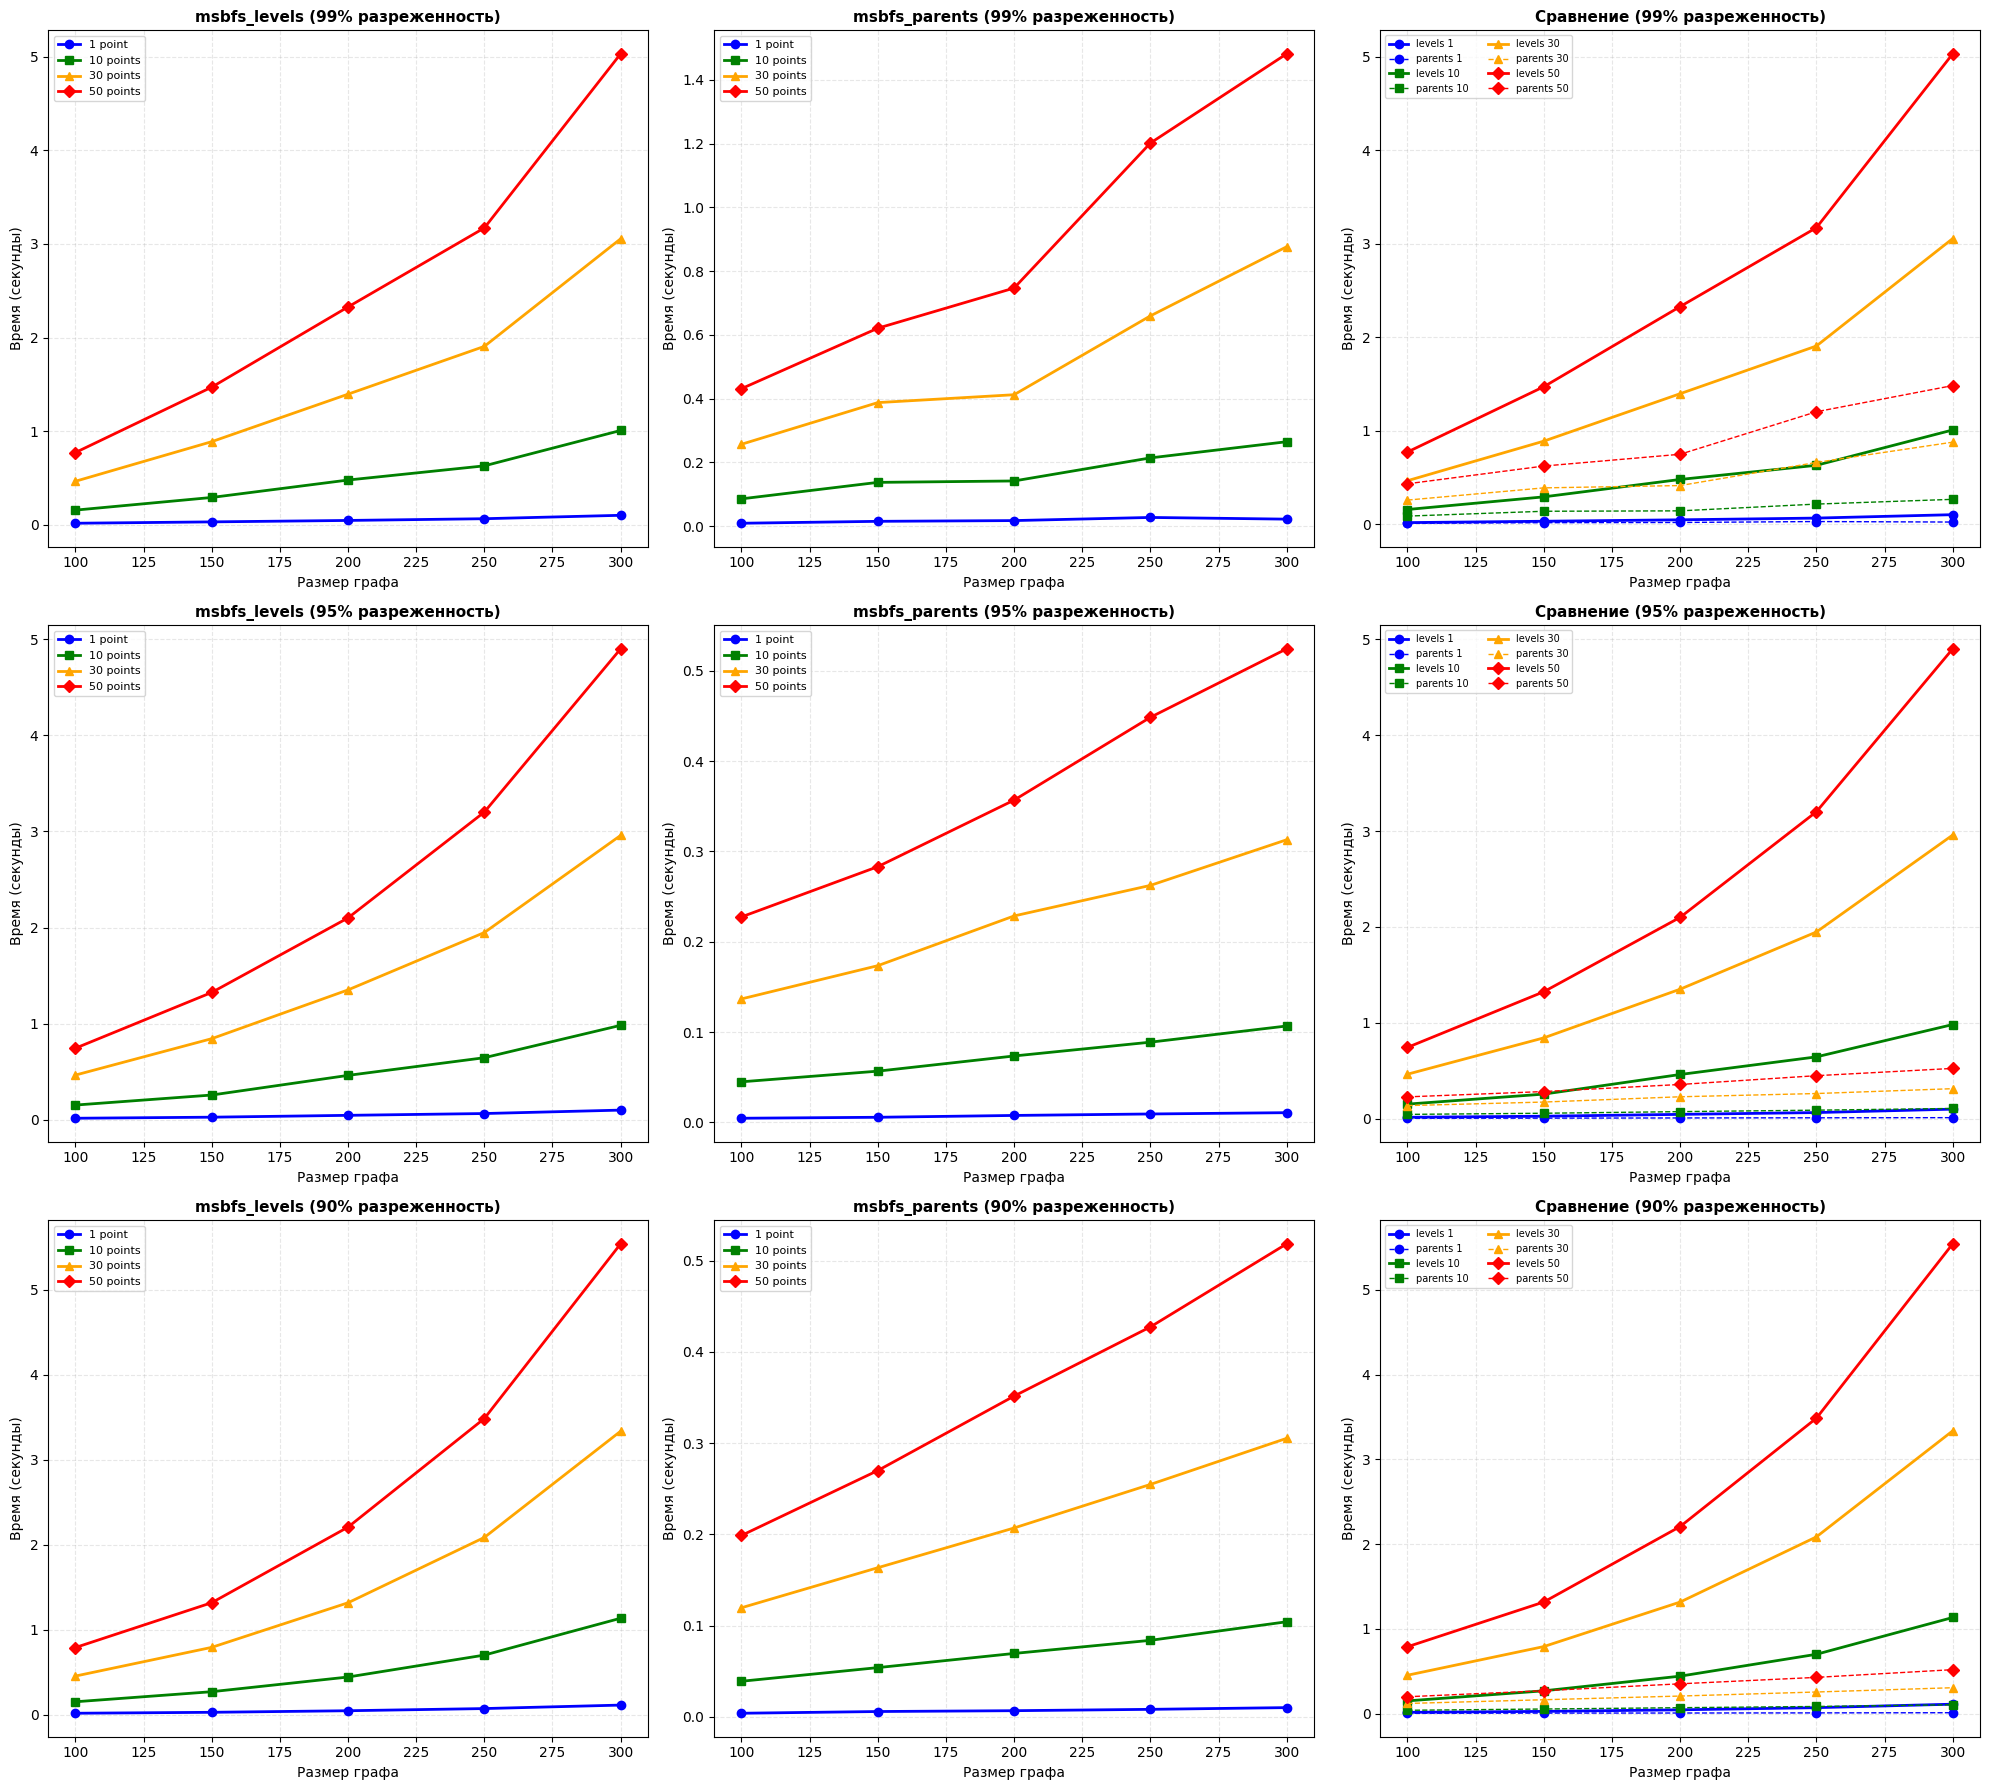

In [400]:
# Создаем фигуру с сеткой подграфиков: строки для sparcity, колонки для типов графиков
sparcity_labels = ['99% разреженность', '95% разреженность', '90% разреженность']

fig, axes = plt.subplots(3, 3, figsize=(20, 18))

# Цвета для разных процентов стартовых вершин
colors = ['blue', 'green', 'orange', 'red']
markers = ['o', 's', '^', 'D']
percentages = ['1 point', '10 points', '30 points', '50 points']

for row, sparcity in enumerate(sparsities):
    # Выбираем данные для текущей разреженности
    if sparcity == 0.99:
        levels_data_list = [msbfs_levels_99_1, msbfs_levels_99_10, msbfs_levels_99_30, msbfs_levels_99_50]
        parents_data_list = [msbfs_parents_99_1, msbfs_parents_99_10, msbfs_parents_99_30, msbfs_parents_99_50]
    elif sparcity == 0.95:
        levels_data_list = [msbfs_levels_95_1, msbfs_levels_95_10, msbfs_levels_95_30, msbfs_levels_95_50]
        parents_data_list = [msbfs_parents_95_1, msbfs_parents_95_10, msbfs_parents_95_30, msbfs_parents_95_50]
    elif sparcity == 0.9:
        levels_data_list = [msbfs_levels_9_1, msbfs_levels_9_10, msbfs_levels_9_30, msbfs_levels_9_50]
        parents_data_list = [msbfs_parents_9_1, msbfs_parents_9_10, msbfs_parents_9_30, msbfs_parents_9_50]
    
    # График 1: msbfs_levels для текущей разреженности
    ax = axes[row, 0]
    for i, (data, color, marker, label) in enumerate(zip(
        levels_data_list, colors, markers, percentages
    )):
        ax.plot(sizes, data, 
                color=color, marker=marker, linewidth=2, markersize=6,
                label=label)
    ax.set_xlabel('Размер графа', fontsize=10)
    ax.set_ylabel('Время (секунды)', fontsize=10)
    ax.set_title(f'msbfs_levels ({sparcity_labels[row]})', fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # График 2: msbfs_parents для текущей разреженности
    ax = axes[row, 1]
    for i, (data, color, marker, label) in enumerate(zip(
        parents_data_list, colors, markers, percentages
    )):
        ax.plot(sizes, data, 
                color=color, marker=marker, linewidth=2, markersize=6,
                label=label)
    ax.set_xlabel('Размер графа', fontsize=10)
    ax.set_ylabel('Время (секунды)', fontsize=10)
    ax.set_title(f'msbfs_parents ({sparcity_labels[row]})', fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # График 3: Сравнение levels vs parents для текущей разреженности
    ax = axes[row, 2]
    for i, percent in enumerate(start_points):
        ax.plot(sizes, levels_data_list[i], 
                color=colors[i], marker=markers[i], linewidth=2, 
                label=f'levels {percent}')
        ax.plot(sizes, parents_data_list[i], 
                color=colors[i], marker=markers[i], linewidth=1, linestyle='--',
                label=f'parents {percent}')
    ax.set_xlabel('Размер графа', fontsize=10)
    ax.set_ylabel('Время (секунды)', fontsize=10)
    ax.set_title(f'Сравнение ({sparcity_labels[row]})', fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Вывод:** 
- Увеличение стартовых точек ведет к увеличению времени работы обоих алгоритмов
- msbfs_parents оказался быстрее алгоритма msbfs_levels
- C увеличением разреженности время работы обоих алгоритмов увеличивается

✔️ (+3 балла) Добавить реализации описанных алгоритмов с использованием других полуколец (`any.pair` для `levels` и `any.first` для `parents`). Добавить тесты для проверки корректности. Провести экспериментальное исследование со сравнением этих реализаций с первоначальными на различных графах.

In [401]:
edges = [
    [3, 0, 3, 5, 6, 0, 6, 1, 6, 2, 4, 1],
    [0, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6],
]

A = Matrix.from_coo(edges[0], edges[1], [True for _ in edges[0]])

msbfs_levels(A, [0, 1, 2]) == msbfs_levels(A, [0, 1, 2], semiring=semiring.any_pair)

True

In [402]:
# Для MSBFS-Levels с булевым фронтом, lor_land и any_pair дают одинаковый результат, 
# потому что любое ненулевое значение интерпретируется как True.
msbfs_levels(A, [0, 1, 2]) == msbfs_levels(A, [0, 1, 2], semiring = semiring.any_pair)

True

In [403]:
# Полукольцр определяет не только факт достижимости, но и какое значение будет выбрано при множественных путях. 
# Для корректной работы BFS родителей нужен min_first (минимальный путь), any_first может дать некорректные результаты, если есть несколько путей до одной вершины.
msbfs_parents(A, [0]) == msbfs_parents(A, [0], semiring = semiring.any_first)

False

Проведем замеры времени только для `MSBFS-Levels` c разными полукольцами.

In [404]:
def testTime(A, iters, start_points):
    
	results = {}
	print(f'Размер матрицы: {A.shape[0]}x{A.shape[1]}, число вершин: {len(start_points)}')

	results = {}

	total_time = 0
	for _ in range(iters):
		start = time.perf_counter()
		msbfs_levels(A, start_points)
		total_time += time.perf_counter() - start
	results['msbfs_levels_lor_land'] = total_time / iters
	
	total_time = 0
	for _ in range(iters):
		start = time.perf_counter()
		msbfs_levels(A, start_points, semiring.any_pair)
		total_time += time.perf_counter() - start
	results['msbfs_levels_any_pair'] = total_time / iters

	return results

In [405]:
files = os.listdir('./data')

iters = 2
sizes = []
results = {}

start_points = [1, 10, 30, 50]
for i in range(len(files) - 3):
	
	A = mmread(f'./data/{files[i]}')
	results[A.shape[0]] = {'msbfs_levels_lor_land': [], 'msbfs_levels_any_pair': []}
 
	for points in start_points:
 
		res = testTime(A, iters, [i for i in range(points)])
		results[A.shape[0]]['msbfs_levels_lor_land'].append(res['msbfs_levels_lor_land'])
		results[A.shape[0]]['msbfs_levels_any_pair'].append(res['msbfs_levels_any_pair'])

# results

Размер матрицы: 767x767, число вершин: 1
Размер матрицы: 767x767, число вершин: 10
Размер матрицы: 767x767, число вершин: 30
Размер матрицы: 767x767, число вершин: 50
Размер матрицы: 1535x1535, число вершин: 1
Размер матрицы: 1535x1535, число вершин: 10
Размер матрицы: 1535x1535, число вершин: 30
Размер матрицы: 1535x1535, число вершин: 50
Размер матрицы: 3071x3071, число вершин: 1
Размер матрицы: 3071x3071, число вершин: 10
Размер матрицы: 3071x3071, число вершин: 30
Размер матрицы: 3071x3071, число вершин: 50
Размер матрицы: 6143x6143, число вершин: 1
Размер матрицы: 6143x6143, число вершин: 10
Размер матрицы: 6143x6143, число вершин: 30
Размер матрицы: 6143x6143, число вершин: 50


In [406]:
sizes = sorted(results.keys())

msbfs_levels_lor_land_1 = []
msbfs_levels_lor_land_10 = []
msbfs_levels_lor_land_30 = []
msbfs_levels_lor_land_50 = []

msbfs_levels_any_pair_1 = []
msbfs_levels_any_pair_10 = []
msbfs_levels_any_pair_30 = []
msbfs_levels_any_pair_50 = []

for size in sizes:
	msbfs_levels_lor_land_1.append(results[size]['msbfs_levels_lor_land'][0])
	msbfs_levels_lor_land_10.append(results[size]['msbfs_levels_lor_land'][1])
	msbfs_levels_lor_land_30.append(results[size]['msbfs_levels_lor_land'][2])
	msbfs_levels_lor_land_50.append(results[size]['msbfs_levels_lor_land'][3])

	msbfs_levels_any_pair_1.append(results[size]['msbfs_levels_any_pair'][0])
	msbfs_levels_any_pair_10.append(results[size]['msbfs_levels_any_pair'][1])
	msbfs_levels_any_pair_30.append(results[size]['msbfs_levels_any_pair'][2])
	msbfs_levels_any_pair_50.append(results[size]['msbfs_levels_any_pair'][3])

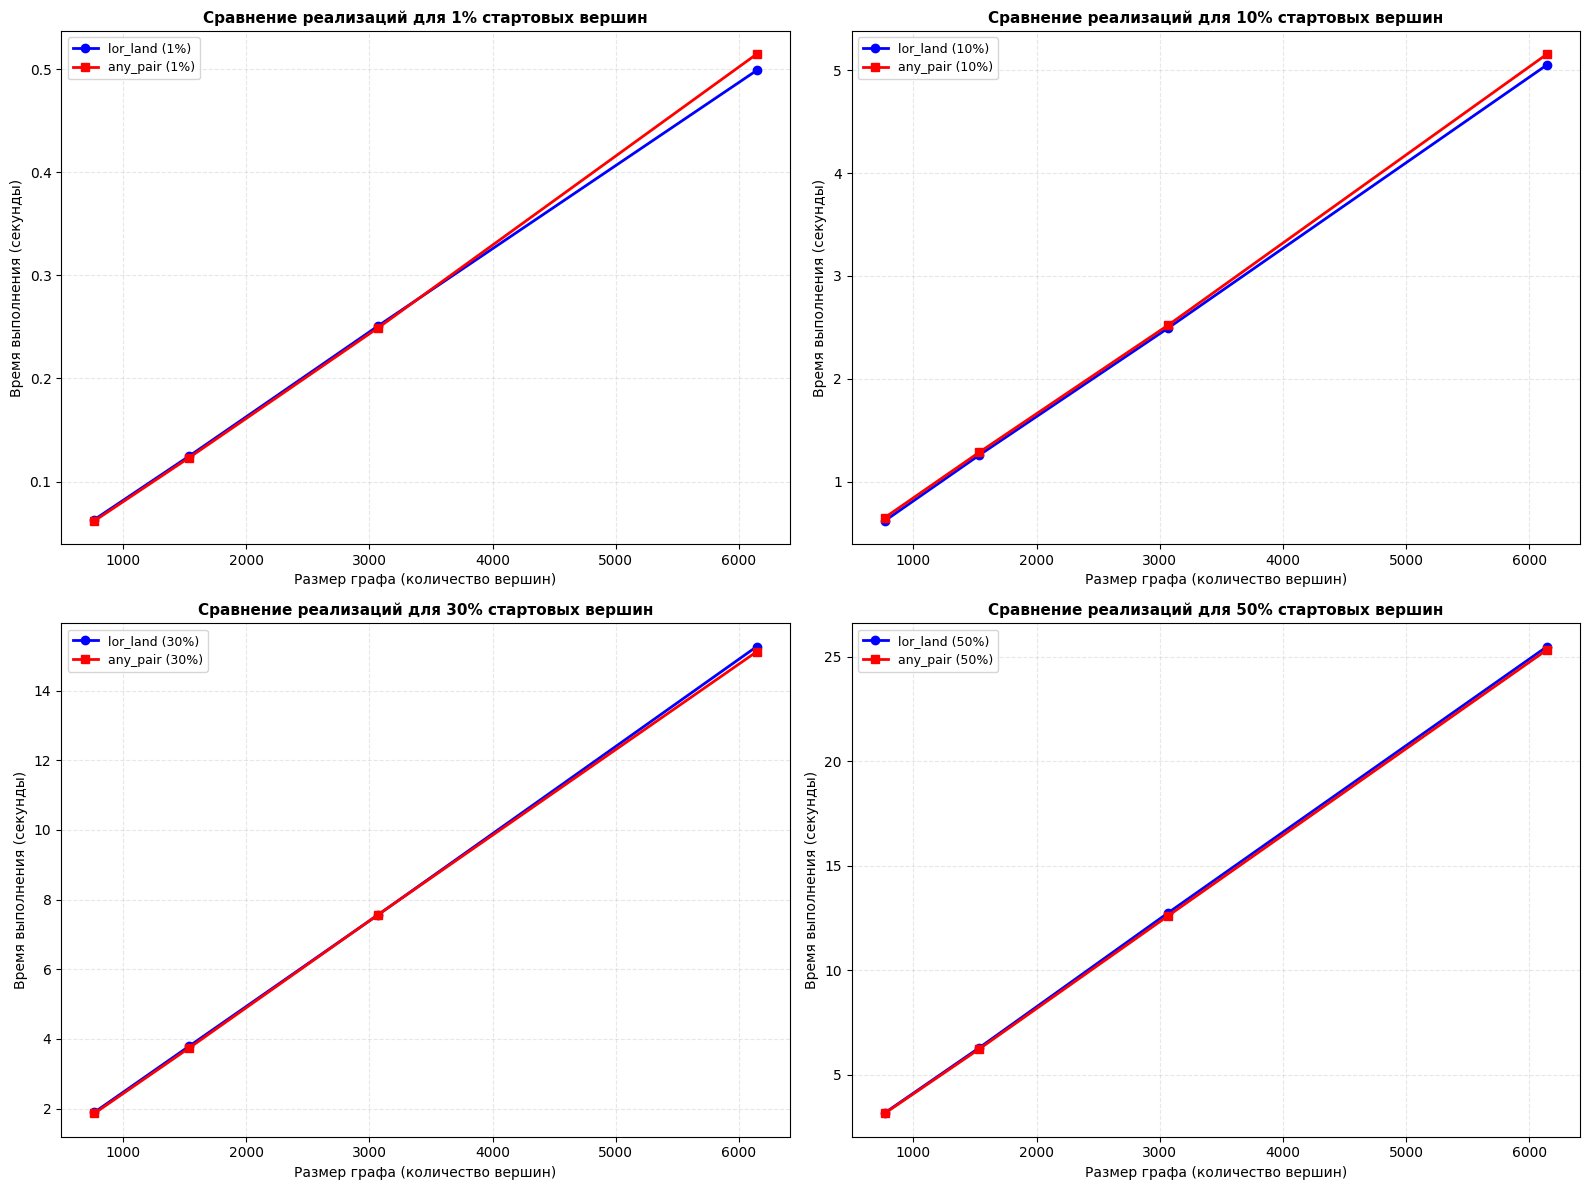

In [407]:
# Создаем фигуру с 4 подграфиками (2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Цвета для разных реализаций
impl_colors = {'lor_land': 'blue', 'any_pair': 'red'}
impl_markers = {'lor_land': 'o', 'any_pair': 's'}
percentages = [1, 10, 30, 50]
percent_labels = ['1%', '10%', '30%', '50%']

# Данные для каждого процента
levels_data_lor = [
    msbfs_levels_lor_land_1,
    msbfs_levels_lor_land_10,
    msbfs_levels_lor_land_30,
    msbfs_levels_lor_land_50
]

levels_data_any = [
    msbfs_levels_any_pair_1,
    msbfs_levels_any_pair_10,
    msbfs_levels_any_pair_30,
    msbfs_levels_any_pair_50
]

# Создаем 4 графика (по одному на каждый процент)
for idx, (percent, label) in enumerate(zip(percentages, percent_labels)):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Данные для текущего процента
    lor_data = levels_data_lor[idx]
    any_data = levels_data_any[idx]
    
    # График для lor_land
    ax.plot(sizes, lor_data, 
            color=impl_colors['lor_land'], 
            marker=impl_markers['lor_land'], 
            linewidth=2, markersize=6,
            label=f'lor_land ({label})')
    
    # График для any_pair
    ax.plot(sizes, any_data, 
            color=impl_colors['any_pair'], 
            marker=impl_markers['any_pair'], 
            linewidth=2, markersize=6,
            label=f'any_pair ({label})')
    
    # Настройки графика
    ax.set_xlabel('Размер графа (количество вершин)', fontsize=10)
    ax.set_ylabel('Время выполнения (секунды)', fontsize=10)
    ax.set_title(f'Сравнение реализаций для {label} стартовых вершин', 
                fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Вывод:** выбор полукольца в алгоритме `MSBFS-Level` на время выполнения алгоритма не влияет.